# Priprema podataka za treniranje 

- Nakon analize podataka, potrebno je srediti podatke tako da mogu što bolje da se prilagode modelima 
- Potrebno je pripremiti podatke tako da mogu da se koriste za treniranje dva različita modela:
    - *CNN* mreža - direktna klasifikacija slika
    - Mreža koja uči slike da predstavi kao embeddinge, pomoću *triplet loss*-a 

## Potrebne biblioteke

In [1]:
import random 
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from pytorch_metric_learning.samplers import MPerClassSampler

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## Konstante

In [2]:
DATA_RAW_DIR = Path("../data/raw")
TRAIN_CSV = DATA_RAW_DIR / "sign_mnist_train.csv"
TEST_CSV = DATA_RAW_DIR / "sign_mnist_test.csv"

IMG_SIZE = 28
NUM_CLASSES = 24
EXCLUDED_LABELS = {9, 25}  # J, Z

SEED = 42
VAL_SIZE = 0.15  # udeo trening skupa izdvojen za validaciju (stratifikovano)
BATCH_SIZE = 64

LETTERS = [chr(ord("A") + i) for i in range(26)]
LABEL_TO_LETTER = {i: LETTERS[i] for i in range(26) if i not in EXCLUDED_LABELS}
LETTER_TO_LABEL = {v: k for k, v in LABEL_TO_LETTER.items()}

## Fiksiranje vrednosti seed
- fiksira se pomoću seed-a random vrednosti, jer bi pri svakom pokretanju vrednosti bile drugačije, što će da oteža i poređenje modela

In [3]:
def set_seed(seed=SEED):
    """Fiksira random seed (python/numpy/torch) radi reproduktivnosti eksperimenata."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Seed fiksiran na {SEED}")

Seed fiksiran na 42


## Učitavanje podataka

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

## Podela podataka na atribute i ciljnu promenljivu

In [5]:
train_labels_full = train_df["label"].to_numpy(dtype=np.int64)
train_pixels_full = (
    train_df.drop(columns=["label"]).to_numpy(dtype=np.float32).reshape(-1, IMG_SIZE, IMG_SIZE)
)

test_labels = test_df["label"].to_numpy(dtype=np.int64)
test_pixels = (
    test_df.drop(columns=["label"]).to_numpy(dtype=np.float32).reshape(-1, IMG_SIZE, IMG_SIZE)
)

## Stratifikovana podela

- podela na *trening*, *validacioni* i *test skup*
- podela se vrši na tri različita skupa, jer trening skup služi za treniranje modela, validacioni za evaluaciju, dok test skup ne treba da bude u momentu učenja modela dostupan, kako bi bila nepristrasna ocena
- *stratifikovana podela* se koristi kako bi svaka glasa zadržala isti procentualni udeo u oba skupa

In [6]:
train_pixels, val_pixels, train_labels, val_labels = train_test_split(
    train_pixels_full,
    train_labels_full,
    test_size=VAL_SIZE,
    stratify=train_labels_full,
    random_state=SEED,
)

for name, pixels, labels in [
    ("train", train_pixels, train_labels),
    ("val", val_pixels, val_labels),
    ("test", test_pixels, test_labels),
]:
    print(
        f"{name:5s}: {pixels.shape[0]:6d} primera, oblik slike {pixels.shape[1:]}, "
        f"{len(np.unique(labels))} klasa"
    )

train:  23336 primera, oblik slike (28, 28), 24 klasa
val  :   4119 primera, oblik slike (28, 28), 24 klasa
test :   7172 primera, oblik slike (28, 28), 24 klasa


**Prikaz podataka nakon stratifikacije**

Najveća razlika u udelu klase izmedju train i val: 0.0002


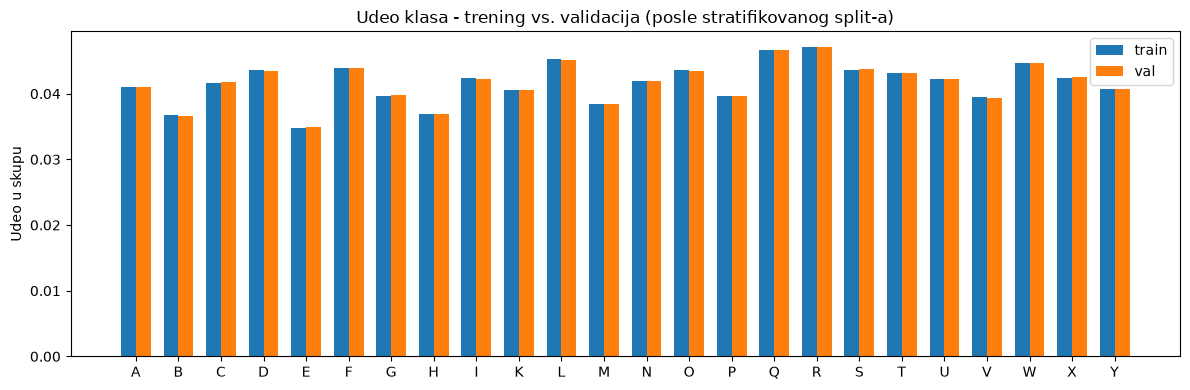

In [7]:
train_props = np.bincount(train_labels) / len(train_labels)
val_props = np.bincount(val_labels) / len(val_labels)

max_diff = np.abs(train_props - val_props).max()
print(f"Najveća razlika u udelu klase izmedju train i val: {max_diff:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
labels_present = sorted(LABEL_TO_LETTER.keys())
letters = [LABEL_TO_LETTER[l] for l in labels_present]
x = np.arange(len(labels_present))
width = 0.35

ax.bar(x - width / 2, [train_props[l] for l in labels_present], width, label="train")
ax.bar(x + width / 2, [val_props[l] for l in labels_present], width, label="val")
ax.set_xticks(x)
ax.set_xticklabels(letters)
ax.set_ylabel("Udeo u skupu")
ax.set_title("Udeo klasa - trening vs. validacija (posle stratifikovanog split-a)")
ax.legend()
plt.tight_layout()
plt.show()

- udeo svake klase u trening i validacionom skupu je približno isti što se može videti iz grafika iznad

## Normalizacija piksela

- normalizacija piksela se vrši zbog stabilnosti i brzine treniranja neuronskih mreža, bolje da podaci budu u osegu *[0, 1]*, umesto *[0, 255]*

In [8]:
train_pixels = train_pixels / 255.0
val_pixels = val_pixels / 255.0
test_pixels = test_pixels / 255.0

for name, pixels in [("train", train_pixels), ("val", val_pixels), ("test", test_pixels)]:
    print(f"{name:5s}: min={pixels.min():.3f}, max={pixels.max():.3f}, mean={pixels.mean():.3f}")

train: min=0.000, max=1.000, mean=0.625
val  : min=0.000, max=1.000, mean=0.624
test : min=0.000, max=1.000, mean=0.630


## Pretvaranje slika iz formata slike (28x28) u PyTorch tenzor format (1x28x28)

In [9]:
class SignMnistDataset(Dataset):
    """Slike (N, 28, 28), vrednosti u [0, 1], i pripadajuće oznake."""

    def __init__(self, pixels, labels, transform=None):
        self.pixels = pixels.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.pixels[idx]).unsqueeze(0)  # (1, 28, 28)
        label = int(self.labels[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

## Augmentacija
- Korisno je pripremiti slike na ovaj način iz razloga što modelu se neće uvek slati ista slika slova, već će na slici biti izvršene blage izmene (npr. blage rotacije)
- na taj način model neće zapamtiti tačne piksele slike, nego mora da nauči iz opšitijih obrazaca i tako se smanjuje overfitting 
- transformacije rotacija, translacija i skaliranje slike ne menjaju značajno osobine same slike
- horizontalni flip se ne koristi tj. ogledalsko okretanje levo-desno, jer ruke nisu simetrične

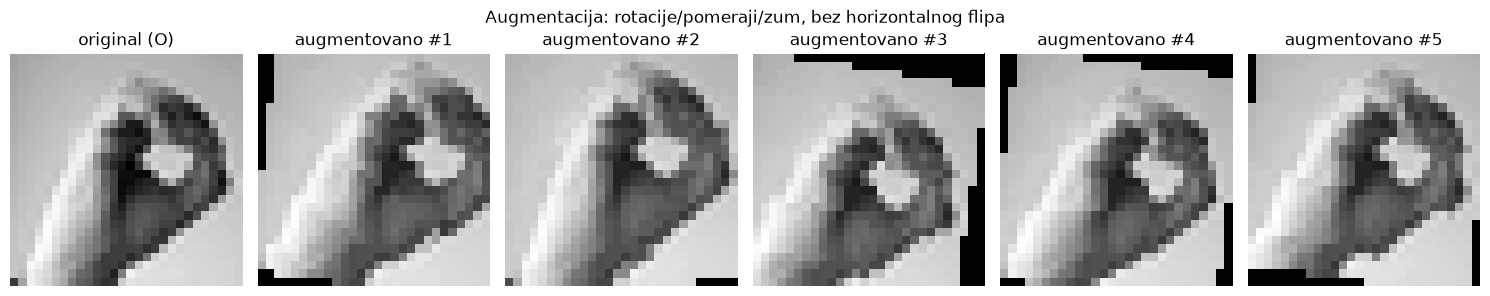

In [10]:
train_transform = transforms.RandomAffine(
    degrees=10,
    translate=(0.08, 0.08),
    scale=(0.9, 1.1),
)

raw_train_ds = SignMnistDataset(train_pixels, train_labels, transform=None)
sample_image, sample_label = raw_train_ds[0]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample_image.squeeze(0), cmap="gray")
axes[0].set_title(f"original ({LABEL_TO_LETTER[sample_label]})")
axes[0].axis("off")

for i in range(1, 6):
    augmented = train_transform(sample_image.unsqueeze(0)).squeeze(0)
    axes[i].imshow(augmented.squeeze(0), cmap="gray")
    axes[i].set_title(f"augmentovano #{i}")
    axes[i].axis("off")

plt.suptitle("Augmentacija: rotacije/pomeraji/zum, bez horizontalnog flipa")
plt.tight_layout()
plt.show()

## Pravljenje DataLoader-a
- pravljenje *batch*-eva
- shuffle - da ne bude fiksni redosled
- augemntacija se dodaje samo na trening skup, kako bi validacioni i test skupovi bili čisti (neizmenjeni) zbog stvarne tačnosti na pravim slikama

In [11]:
train_ds = SignMnistDataset(train_pixels, train_labels, transform=train_transform)
val_ds = SignMnistDataset(val_pixels, val_labels)
test_ds = SignMnistDataset(test_pixels, test_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch slika: {images.shape}, dtype={images.dtype}")
print(f"Batch oznaka: {labels.shape}, dtype={labels.dtype}")
print(f"Opseg piksela u batch-u: [{images.min():.3f}, {images.max():.3f}]")

Batch slika: torch.Size([64, 1, 28, 28]), dtype=torch.float32
Batch oznaka: torch.Size([64]), dtype=torch.int64
Opseg piksela u batch-u: [0.000, 1.000]


## Balansirano uzorkovanje po klasi 
- potrebno za *triplet loss* (rad sa trojkama slika: (anchor, positive (ista klasa), negative (druga klasa)))
- umesto nasumičnog mešanja, biraju se indeksi tako da svaka klasa u bacth-u bude zastupljena tačno *m* primera

In [12]:
M_PER_CLASS = 4

balanced_sampler = MPerClassSampler(
    train_ds.labels,
    m=M_PER_CLASS,
    length_before_new_iter=len(train_ds.labels),
)
balanced_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=balanced_sampler)

images, labels = next(iter(balanced_loader))
unique, counts = np.unique(labels.numpy(), return_counts=True)
print(f"Broj primera po klasi u batch-u (očekivano: svi jednaki m={M_PER_CLASS}, osim eventualno ostatka):")
for u, c in zip(unique, counts):
    print(f"  {LABEL_TO_LETTER[u]}: {c}")

Broj primera po klasi u batch-u (očekivano: svi jednaki m=4, osim eventualno ostatka):
  A: 4
  C: 4
  E: 4
  G: 4
  I: 4
  K: 4
  L: 4
  N: 4
  O: 4
  P: 4
  Q: 4
  S: 4
  V: 4
  W: 4
  X: 4
  Y: 4


## Provera funkcije set_seed
- treba da budu fiksirani podaci kao i na početku notebook-a, tako da podela na trening i validacioni skup budu iste

In [13]:
set_seed()
train_pixels_check, val_pixels_check, train_labels_check, val_labels_check = train_test_split(
    train_pixels_full,
    train_labels_full,
    test_size=VAL_SIZE,
    stratify=train_labels_full,
    random_state=SEED,
)

same_split = np.array_equal(train_labels, train_labels_check) and np.array_equal(
    val_labels, val_labels_check
)
print(f"Split je reproduktivan sa fiksnim seed-om: {same_split}")

Split je reproduktivan sa fiksnim seed-om: True


## Čuvanje podataka na disku

In [14]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(exist_ok=True)

np.savez_compressed(
    processed_dir / "sign_mnist_prepared.npz",
    train_pixels=train_pixels, train_labels=train_labels,
    val_pixels=val_pixels, val_labels=val_labels,
    test_pixels=test_pixels, test_labels=test_labels,
)
print(f"Sačuvano u {processed_dir / 'sign_mnist_prepared.npz'}")

Sačuvano u ../data/processed/sign_mnist_prepared.npz
